# 19. V5.5 — phase-aware full-budget Pair Generator

Ноутбук проверяет честный вариант V5.5: сессия **не останавливается** после soft-stop marker, а продолжается до 25 A/B-шагов. Marker используется только как продуктовый сигнал: «профиль уже можно сохранить, но пользователь может продолжить уточнение».

Фиксы в этой версии:

- full-session source usage теперь нормируется по всей сессии, поэтому stacked bar суммируется в `1.0`;
- retained quality считается агрегированно по средним distance, без странных значений вроде `269%`;
- отдельно показаны шаги до/после marker, distance на marker vs финал, и post-marker типы вопросов.


In [1]:
from pathlib import Path
import os
import sys


PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "research" / "eq_personalization").exists():
    PROJECT_ROOT = PROJECT_ROOT / "research" / "eq_personalization"
elif not (PROJECT_ROOT / "personalization").exists():
    # если ноутбук открыт из папки notebooks
    PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)


PROJECT_ROOT: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization
Python: C:\Users\makcc\PycharmProjects\EarLoop\.venv\Scripts\python.exe


In [2]:
import importlib.util
import pandas as pd
from IPython.display import Image, display

exp_path = PROJECT_ROOT / "experiments" / "19_phase_aware_full_budget_pair_generator.py"
spec = importlib.util.spec_from_file_location("v55_exp", exp_path)
v55_exp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(v55_exp)

from personalization.phase_aware_full_budget_v55 import (
    run_v55_comparison_on_dataset,
    summarize_v55_sessions,
    source_usage_table_v55,
    post_marker_source_usage_table_v55,
    phase_step_budget_table,
    save_v55_outputs,
)
from personalization.batch_eval import win_rates_vs_baseline
from personalization.plotting import use_article_style

use_article_style()


In [3]:
DATASET_PATH = PROJECT_ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
SAMPLE_PER_MODE = None
N_STEPS = 25
PREFIX = "article_v55_phase_aware_full_budget"

dataset = pd.read_csv(DATASET_PATH)
dataset_eval = v55_exp.sample_dataset(dataset, SAMPLE_PER_MODE)
print(dataset_eval.groupby("target_mode").size())


target_mode
archetype8d    100
random8d       100
semantic4d     100
semantic6d     100
dtype: int64


In [4]:
sessions, steps, curves = run_v55_comparison_on_dataset(
    dataset=dataset_eval,
    include_previous_v5=False,
    n_steps=N_STEPS,
)

summary = summarize_v55_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline="semantic_active_v21")
source_usage = source_usage_table_v55(steps)
post_marker_source_usage = post_marker_source_usage_table_v55(steps, target_mode="archetype8d")
step_budget = phase_step_budget_table(sessions, target_mode="archetype8d")

metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
fig_dir = PROJECT_ROOT / "outputs" / "figures"
table_dir = PROJECT_ROOT / "outputs" / "tables"
metrics_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

save_v55_outputs(
    sessions, steps, summary, win_rates, source_usage, step_budget, metrics_dir,
    prefix=PREFIX, post_marker_source_usage=post_marker_source_usage,
)
step_budget.to_csv(table_dir / f"{PREFIX}_step_budget_archetype8d.csv", index=False)
post_marker_source_usage.to_csv(table_dir / f"{PREFIX}_post_marker_source_usage_archetype8d.csv", index=False)

print("saved metrics:", metrics_dir)


saved metrics: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\metrics


In [5]:
v55_exp.plot_final_distance_by_target(summary, fig_dir, PREFIX)
v55_exp.plot_convergence_archetype(curves, summary, fig_dir, PREFIX)
v55_exp.plot_phase_step_budget(step_budget, fig_dir, PREFIX)
v55_exp.plot_stop_vs_final_distance(summary, fig_dir, PREFIX)
v55_exp.plot_extra_gain_after_marker(summary, fig_dir, PREFIX)
v55_exp.plot_source_usage(source_usage, fig_dir, PREFIX)
v55_exp.plot_post_marker_source_usage(post_marker_source_usage, fig_dir, PREFIX)

print("saved figures:", fig_dir)


saved figures: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures


## Основные графики

article_v55_phase_aware_full_budget_convergence_archetype8d.png


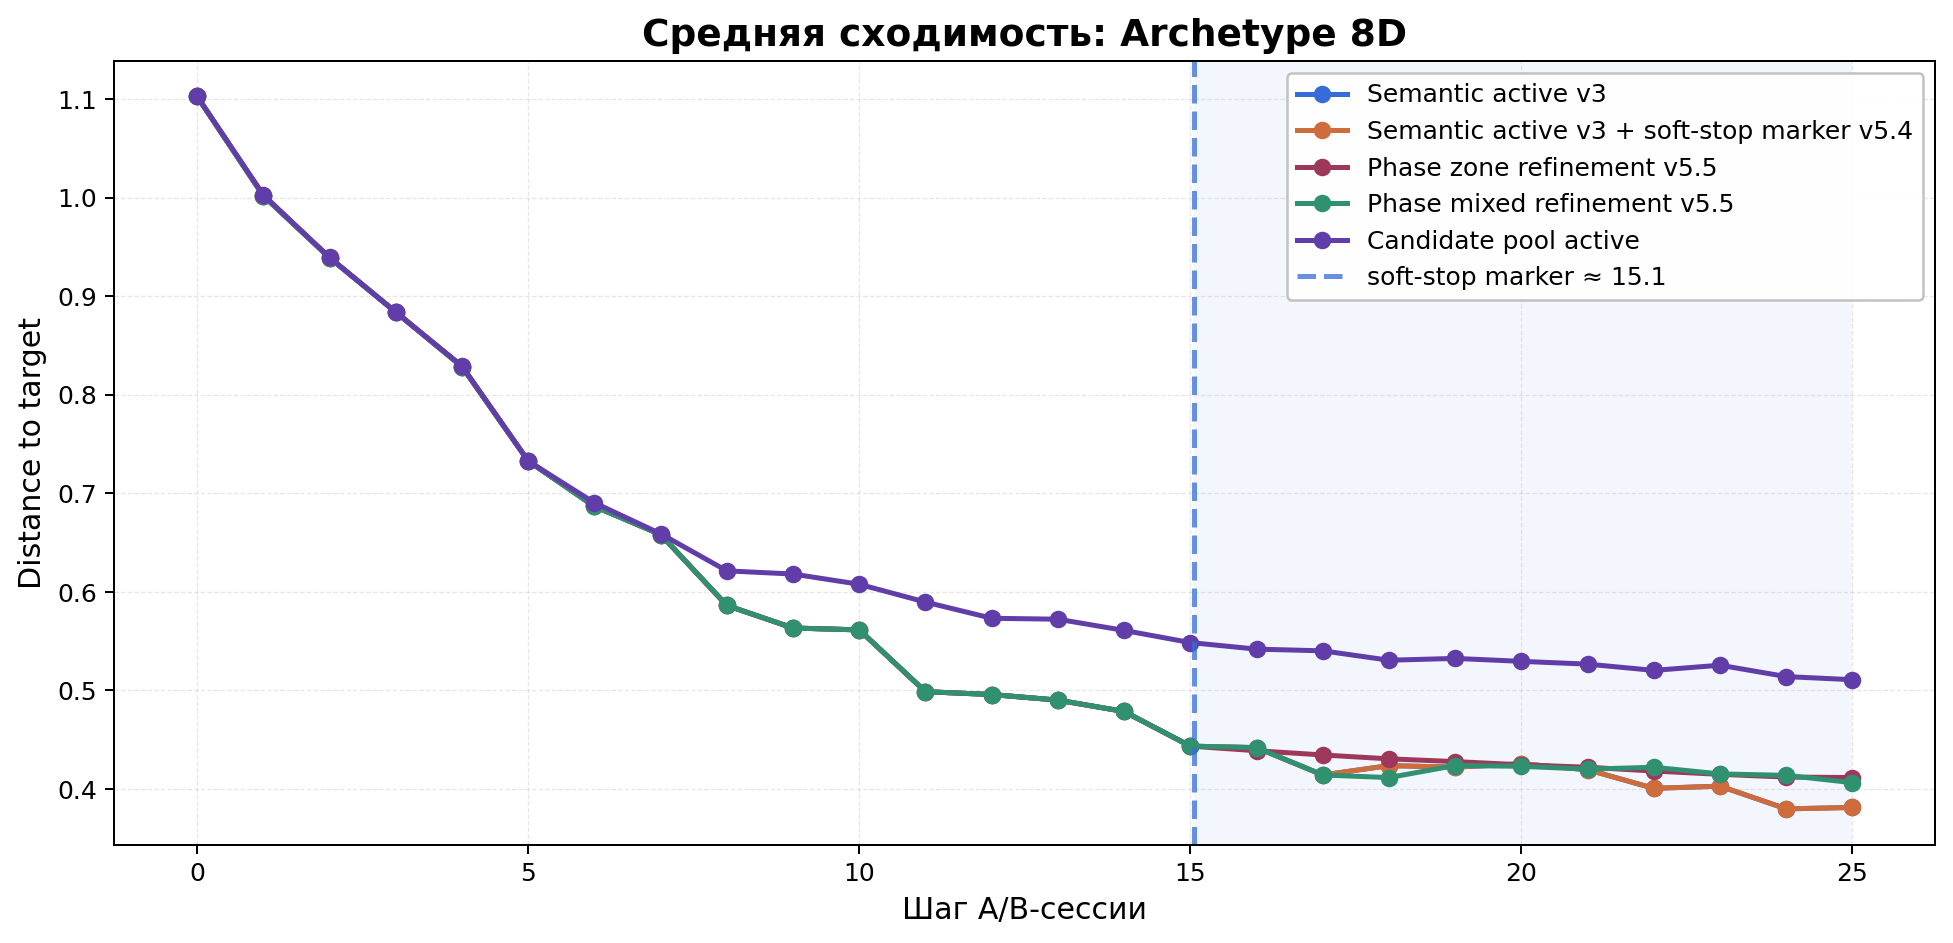

article_v55_phase_aware_full_budget_steps_before_after_soft_stop_archetype8d.png


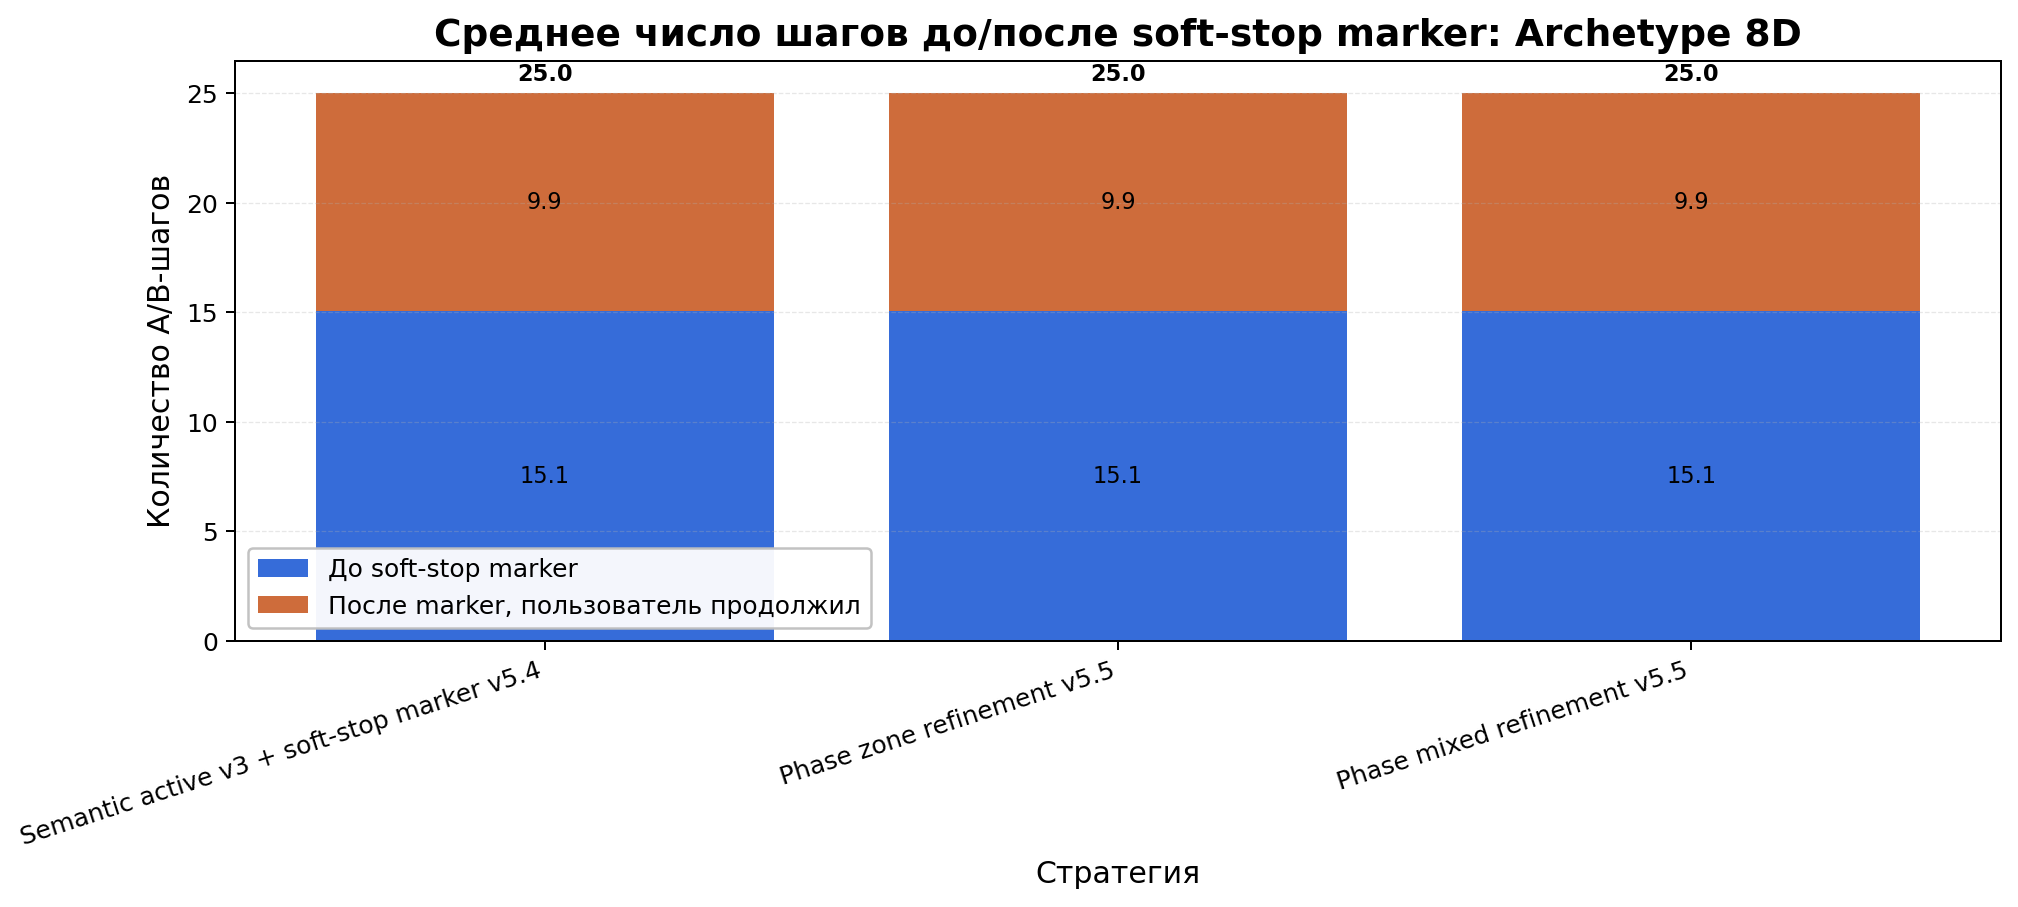

article_v55_phase_aware_full_budget_stop_vs_final_distance_archetype8d.png


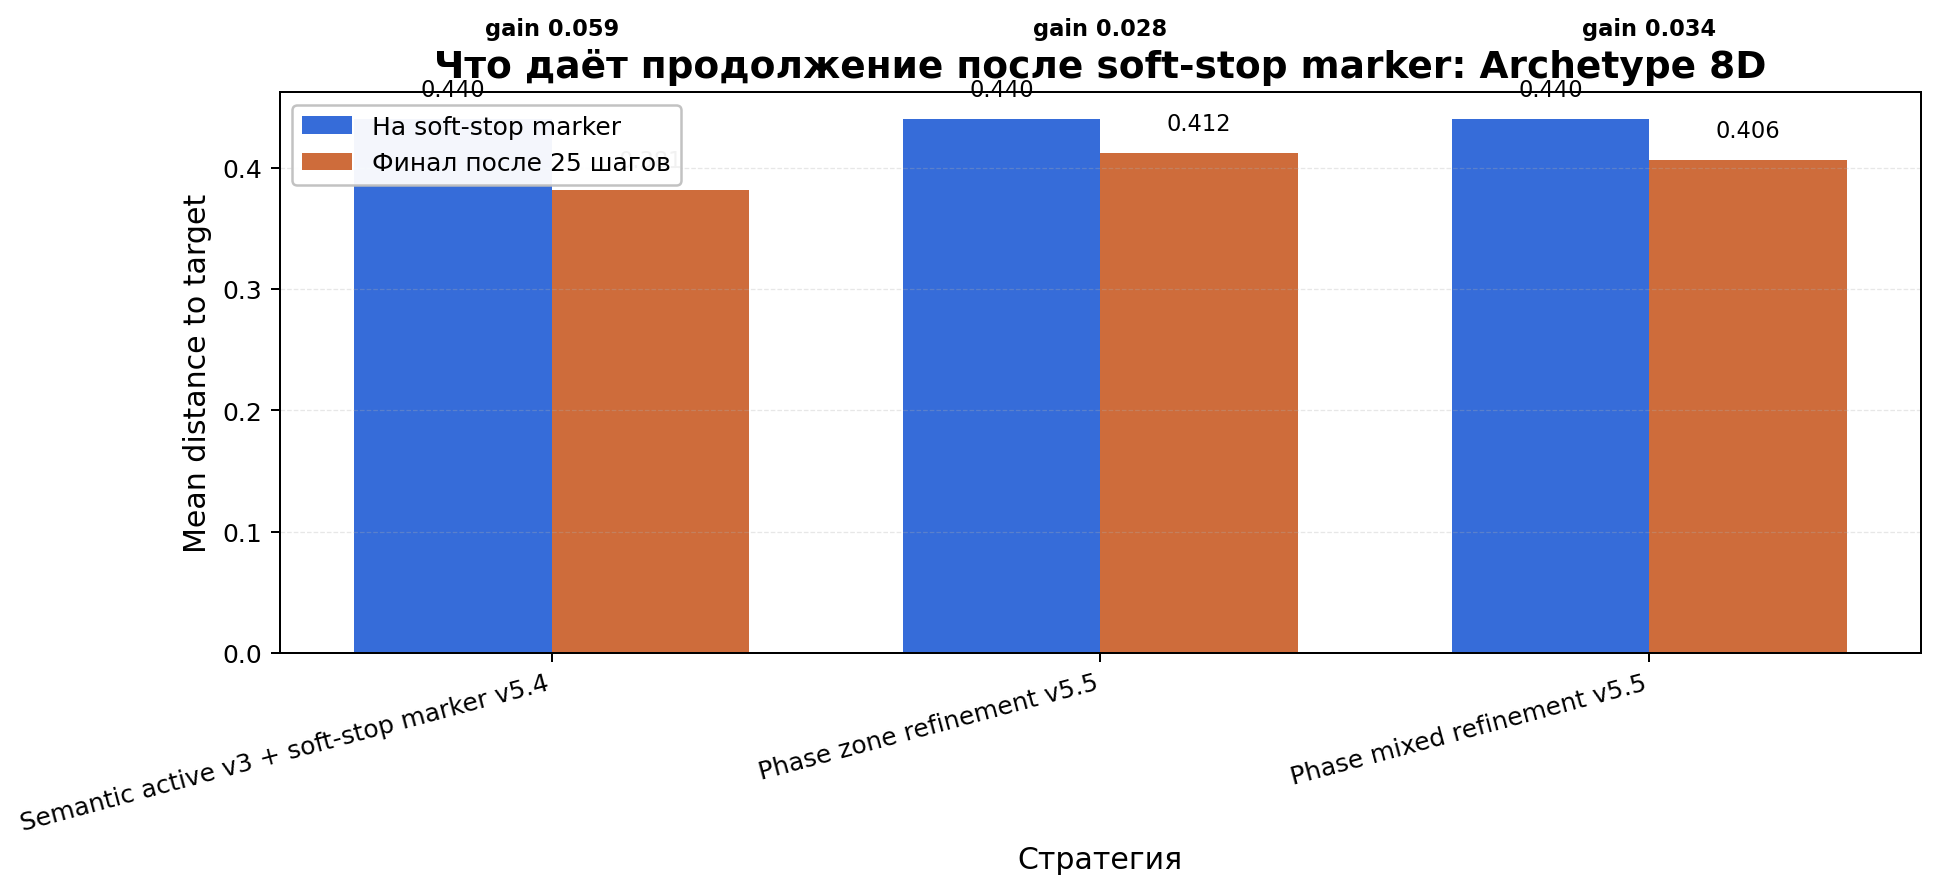

article_v55_phase_aware_full_budget_extra_gain_after_soft_stop_archetype8d.png


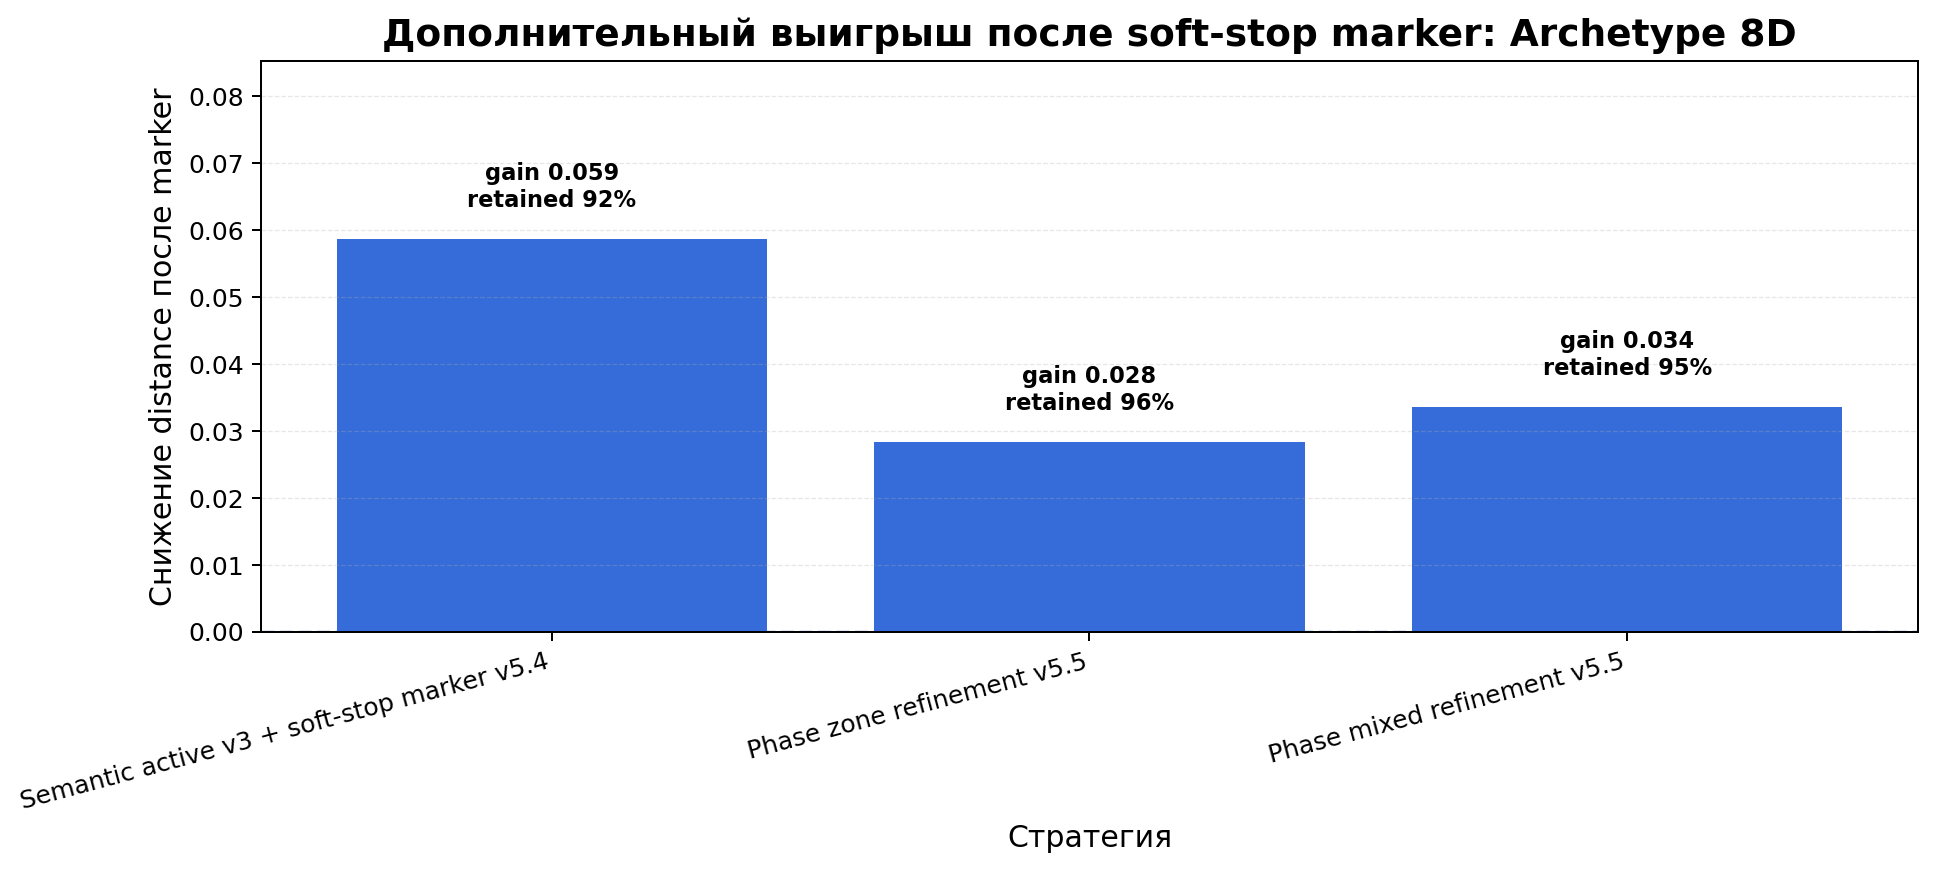

article_v55_phase_aware_full_budget_source_usage_archetype8d.png


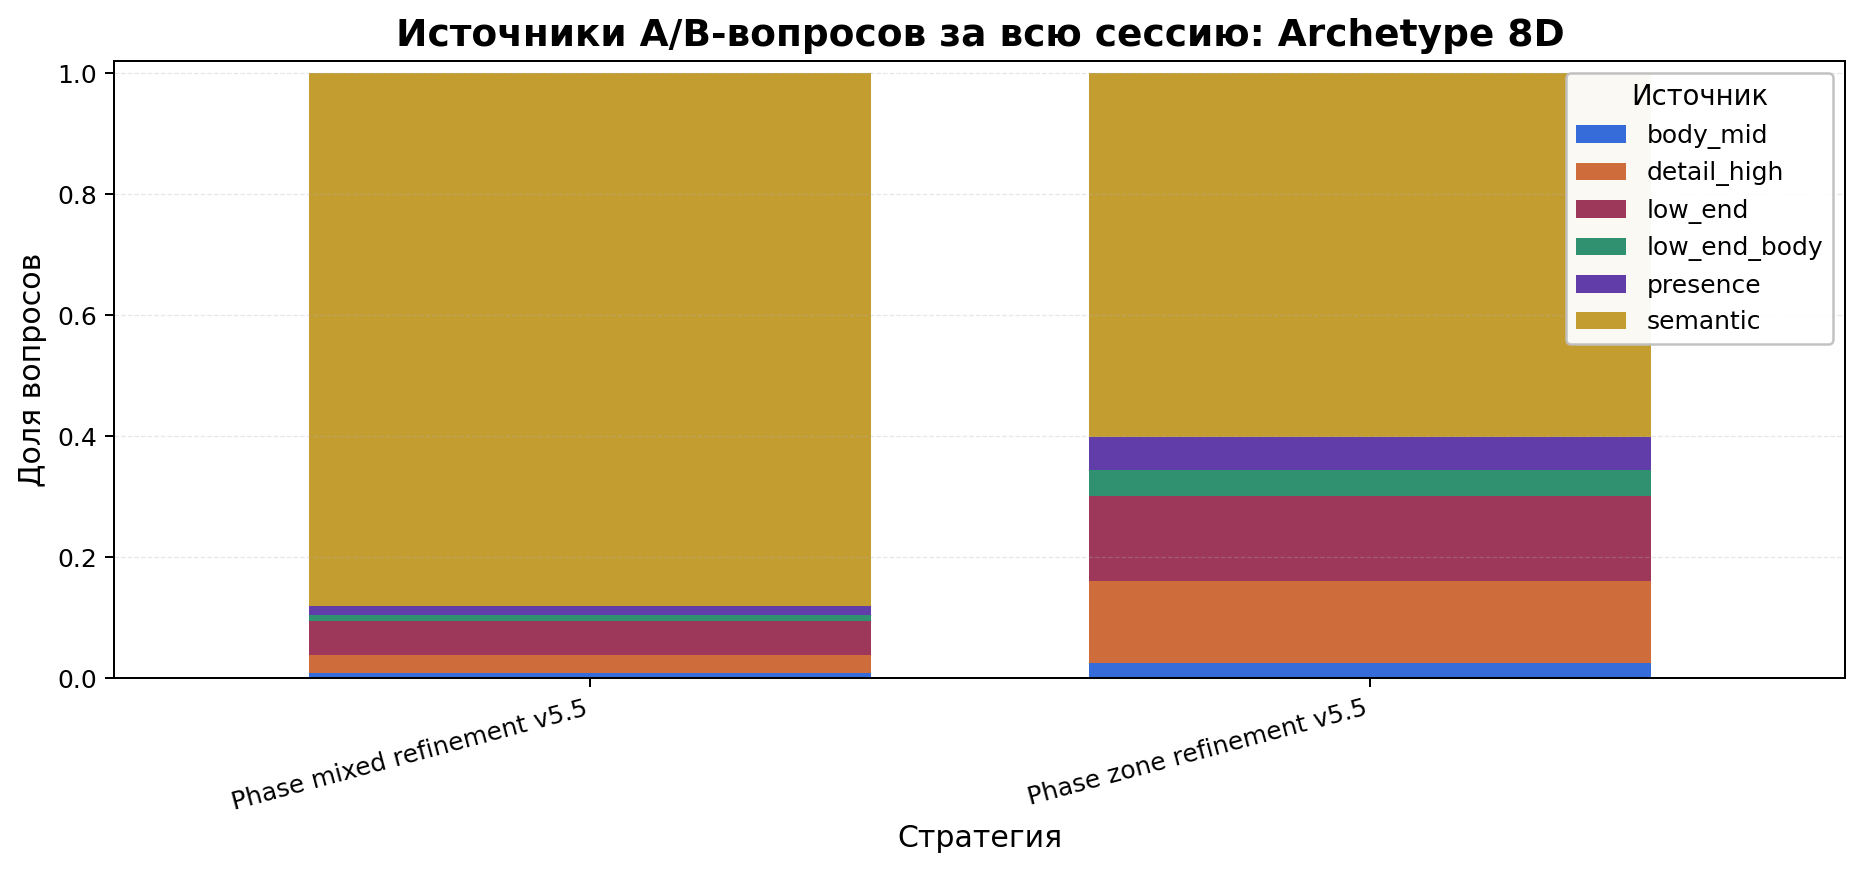

article_v55_phase_aware_full_budget_post_marker_source_usage_archetype8d.png


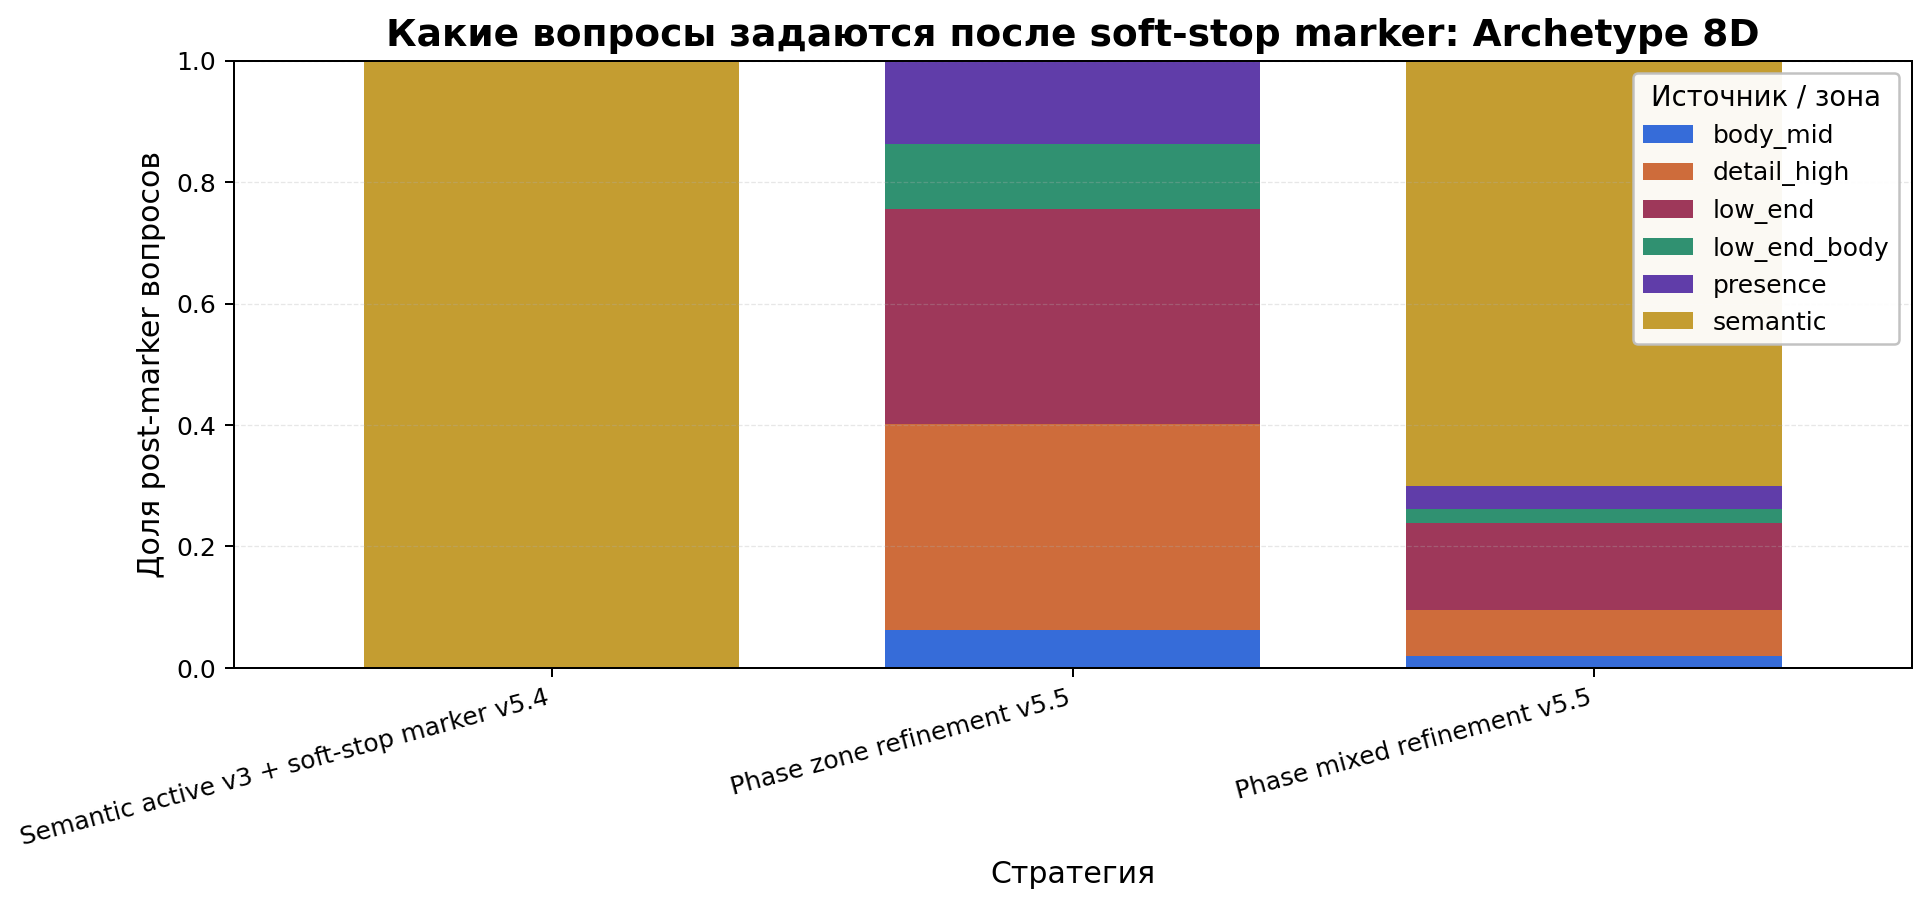

article_v55_phase_aware_full_budget_mean_final_distance_by_target.png


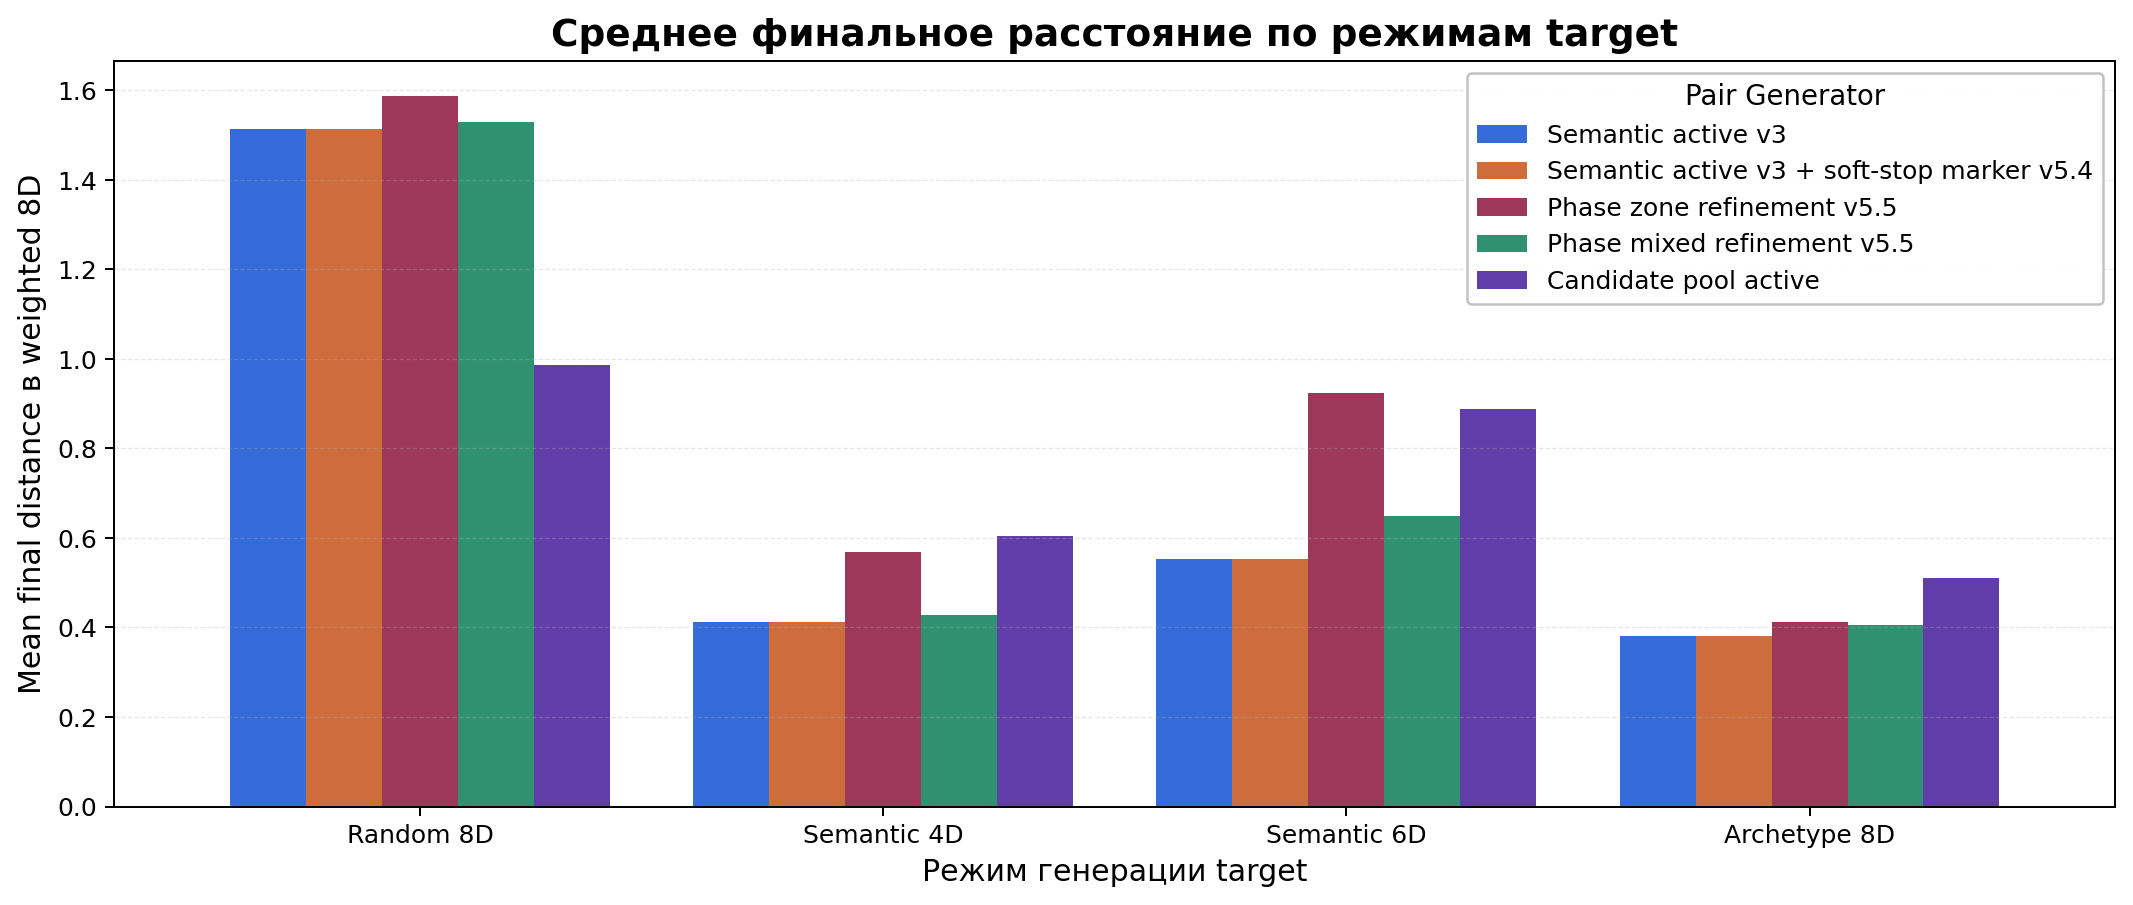

In [6]:
for name in [
    "convergence_archetype8d",
    "steps_before_after_soft_stop_archetype8d",
    "stop_vs_final_distance_archetype8d",
    "extra_gain_after_soft_stop_archetype8d",
    "source_usage_archetype8d",
    "post_marker_source_usage_archetype8d",
    "mean_final_distance_by_target",
]:
    path = fig_dir / f"{PREFIX}_{name}.png"
    print(path.name)
    display(Image(filename=str(path)))


## Таблицы

In [28]:
article_strategies = v55_exp.ARTICLE_STRATEGIES
summary_view = summary[summary["strategy"].isin(article_strategies)].copy()
summary_view[[
    "target_mode", "strategy", "users",
    "mean_recommended_stop_step", "mean_steps_before_recommendation", "mean_steps_after_recommendation",
    "mean_distance_at_recommended_stop", "mean_final_distance", "mean_extra_gain_after_stop",
    "aggregate_retained_quality_at_stop_pct",
]].sort_values(["target_mode", "mean_final_distance"])


KeyError: "['aggregate_retained_quality_at_stop_pct'] not in index"

## Короткий вывод

- `Semantic active v3 + soft-stop marker v5.4` показывает, на каком шаге система уже могла бы предложить сохранить профиль, но не останавливает оптимизацию.
- После marker дополнительные вопросы всё ещё дают выигрыш по distance.
- Полный переход в `zone refinement` после marker обычно добирает меньше качества, чем продолжение semantic backbone.
- `mixed refinement` ближе к baseline: он оставляет semantic backbone основным, но иногда добавляет локальные refinement-вопросы.
